Group 2: Annu Choudhary, Diego Orduz, Lina Sachica, Anika Saraf

---



## Introduction

The Lodging dataset, collected by a travel agency in 2024, contains information about various lodging facilities such as hotels, cabins, beach houses and resorts. The dataset includes both **categorical** and **numerical** variables that describe features like the **type of hotel**, **location**, **pricing**, **customer reviews**, and **room types**. The purpose of our analysis is to analyze revenue performance by category, track customer satisfaction across lodging types and understand booking behaviors and seasonal trends.

### Types of Data:
- **Categorical Variables:** These include variables such as Category (HotelRoom, MountainCabin, BeacHouse) , Date , Type (Travel, Vacation), and Names.
- **Numerical Variables:** These include variables such as average_revenue, Rating and Price.

This dataset is useful for trend analysis, hotel performance insights, and understanding customer preferences.


In [ ]:
# Install required R libraries
install.packages("tidyverse")
install.packages("ggplot2")
install.packages("dplyr")
install.packages("reshape2")
install.packages("readxl")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘plyr’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)





---



## Data Pre-Processing
1. Read the dataset and retrieve overview with str() and summary().

In [ ]:
# Load tidyverse library
library(tidyverse)

# Read the CSV file
dataset <- read.csv("Lodging_dataset633300102.csv" )

# Preview the dataset
head(dataset)

# Check structure of the dataset
str(dataset)

# Summary statistics
summary(dataset)
dim(dataset)

# checks empty strings and NA values
missing_vals<- sapply(dataset, function(x) sum(is.na(x) | trimws(x) == ""))
missing_vals

# identifies columns with only NA values to make replacement easier
colSums(is.na(dataset))

,unique_id,date,name,category,type,rating,price,average_revenue
,<dbl>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>
1,1.405251e+14,2024-10-06,Presidential Suite,HotelRoom,Travel,1,1026,89427.71
2,1.405251e+14,2024-07-24,Executive Suite,HotelRoom,Travel,2,656,97402.71
3,1.405251e+14,2024-07-21,Executive Suite,HotelRoom,Travel,1,673,77797.96
4,1.405251e+14,2024-10-05,Executive Suite,HotelRoom,Travel,2,668,99784.76
5,1.405251e+14,2024-07-29,Presidential Suite,HotelRoom,Travel,3,1038,93703.15
6,1.405251e+14,2024-11-06,Presidential Suite,HotelRoom,Travel,3,975,85653.51


'data.frame':	12000 obs. of  8 variables:
 $ unique_id      : num  1.41e+14 1.41e+14 1.41e+14 1.41e+14 1.41e+14 ...
 $ date           : chr  "2024-10-06" "2024-07-24" "2024-07-21" "2024-10-05" ...
 $ name           : chr  "Presidential Suite" "Executive Suite" "Executive Suite" "Executive Suite" ...
 $ category       : chr  "HotelRoom" "HotelRoom" "HotelRoom" "HotelRoom" ...
 $ type           : chr  "Travel" "Travel" "Travel" "Travel" ...
 $ rating         : int  1 2 1 2 3 3 1 3 1 2 ...
 $ price          : int  1026 656 673 668 1038 975 698 1034 693 594 ...
 $ average_revenue: num  89428 97403 77798 99785 93703 ...


   unique_id             date               name             category        
 Min.   :1.405e+14   Length:12000       Length:12000       Length:12000      
 1st Qu.:1.405e+14   Class :character   Class :character   Class :character  
 Median :1.405e+14   Mode  :character   Mode  :character   Mode  :character  
 Mean   :1.405e+14                                                           
 3rd Qu.:1.405e+14                                                           
 Max.   :1.405e+14                                                           
                                                                             
     type               rating          price        average_revenue 
 Length:12000       Min.   :1.000   Min.   : 300.0   Min.   : 60000  
 Class :character   1st Qu.:1.000   1st Qu.: 500.0   1st Qu.: 84125  
 Mode  :character   Median :2.000   Median : 707.0   Median : 91161  
                    Mean   :2.089   Mean   : 726.5   Mean   : 89317  
                    3rd Qu

[1] 12000     8

unique_id            date            name        category            type 
              0             484               0               0               0 
         rating           price average_revenue 
            498             953             953

unique_id            date            name        category            type 
              0               0               0               0               0 
         rating           price average_revenue 
            498             953             953

### Missing Value Treatment

Missing values were handled as follows:

- **Categorical Variables:** Filled using the **mode** (most frequently occurring value) for each column.
- **Numerical Variables:** Filled using the **median**, which is more robust to outliers than the mean.

This approach helped preserve the overall distribution and integrity of the dataset for further analysis.


2. To handle the empty strings in the date column, we specifically utilized the table() and which.max() functions to identify the mode, then replaced empty strings/missing values with the most frequently occurring date (mode).

In [ ]:
# Step 2: Handle missing dates
dataset$date <- as.Date(dataset$date)
date_freq <- table(dataset$date)
mode_date <- as.Date(names(which.max(date_freq)))
dataset$date[dataset$date == ""] <- mode_date
dataset$date[is.na(dataset$date)] <- mode_date


ERROR: Error: object 'dataset' not found


3. For numeric columns (rating, price, average_revenue), we used the as.numeric() function to convert the columns in the dataset to numeric types, and replaced missing values (NA) in each column with their respective median values using median() with the na.rm = TRUE parameter to ignore NAs.

In [ ]:
# Step 3: Handle missing  and NA's ratings, prices, and revenues
dataset$rating <- as.numeric(dataset$rating)
dataset$rating[is.na(dataset$rating)] <- median(dataset$rating, na.rm = TRUE)

dataset$price <- as.numeric(dataset$price)
dataset$price[is.na(dataset$price)] <- median(dataset$price, na.rm = TRUE)

dataset$average_revenue <- as.numeric(dataset$average_revenue)
dataset$average_revenue[is.na(dataset$average_revenue)] <- median(dataset$average_revenue, na.rm = TRUE)
### check  again if missing values and NA are there
missing_vals<- sapply(dataset, function(x) sum(is.na(x) | trimws(x) == ""))
missing_vals

colSums(is.na(dataset))






unique_id            date            name        category            type 
              0               0               0               0               0 
         rating           price average_revenue 
              0               0               0

unique_id            date            name        category            type 
              0               0               0               0               0 
         rating           price average_revenue 
              0               0               0

4. Since there were no remaining missing values to address (as shown above), we proceeded to the next step, convering categorical variables (name, category, type) to factors using the as.factor() function.

In [ ]:
# Step 4: Convert categorical variables to factors
dataset$name <- as.factor(dataset$name)
dataset$category <- as.factor(dataset$category)
dataset$type <- as.factor(dataset$type)

5. Finally, we identified duplicate rows in the dataset using the duplicated() function and stored the result in the duplicates variable. We then calculated the total number of duplicate rows using sum(duplicates) and printed the count along with a descriptive message using the paste() function.

In [ ]:
# Step 5: Check for duplicates
duplicates <- duplicated(dataset)
print(paste("Number of duplicate rows:", sum(duplicates)))

[1] "Number of duplicate rows: 0"


6. We removed duplicate rows from the dataset by filtering out entries flagged as duplicates using the !duplicated() function, ensuring that the resulting dataset only contains unique rows.

In [ ]:
# Remove duplicates
dataset <- dataset[!duplicated(dataset), ]

7. Saved the cleaned dataset using the write.csv() function.

In [ ]:
# Step 6: Save the cleaned dataset
write.csv(dataset, "Cleaned_Dataset.csv", row.names = FALSE)
print("Dataset has been cleaned and saved.")


[1] "Dataset has been cleaned and saved."


8. We reloaded the cleaned data to get a comprehensive overview and ensure that there was nothing left to address in the initial preprocessing steps.

In [ ]:
# Load the cleaned dataset
cleaned_data <- read.csv("Cleaned_Dataset.csv")

# Check the dimensions of the cleaned data
dimensions <- dim(cleaned_data)
print(paste("Number of rows:", dimensions[1]))
print(paste("Number of columns:", dimensions[2]))
str(cleaned_data)


[1] "Number of rows: 12000"
[1] "Number of columns: 8"
'data.frame':	12000 obs. of  8 variables:
 $ unique_id      : num  1.41e+14 1.41e+14 1.41e+14 1.41e+14 1.41e+14 ...
 $ date           : chr  "2024-10-06" "2024-07-24" "2024-07-21" "2024-10-05" ...
 $ name           : chr  "Presidential Suite" "Executive Suite" "Executive Suite" "Executive Suite" ...
 $ category       : chr  "HotelRoom" "HotelRoom" "HotelRoom" "HotelRoom" ...
 $ type           : chr  "Travel" "Travel" "Travel" "Travel" ...
 $ rating         : int  1 2 1 2 3 3 1 3 1 2 ...
 $ price          : int  1026 656 673 668 1038 975 698 1034 693 594 ...
 $ average_revenue: num  89428 97403 77798 99785 93703 ...




---



## **Visualization**

As mentioned in the introduction, our objective is to analyze customer satisifcation, identify most profitable rentals and examine lodging booking trends. We explored both categorical and numerical variables through the visualizations below.


(Note: Our visualizations analyze all variables, except for the binary variable 'Type' (which includes "Travel" or "Vacation"). We felt it didn't provide any meaningful insights for the analysis.)

# 1. Bar Chart

In [ ]:
library(ggplot2)

# Bar chart comparing average revenue by category
ggplot(cleaned_data, aes(x = category, y = average_revenue, fill = category)) +
  geom_bar(stat = "identity") +
  theme_minimal() +
  labs(title = "Average Revenue by Category", x = "Category", y = "Average Revenue") +
  scale_fill_brewer(palette = "Set3")


This bar chart show the average revenue generated by the three lodging categories: Beach House (green), Hotel Room (yellow), and Mountain Cabin (purple).

Beach Houses exhibit the lowest average revenue among the three categories, suggesting less profitability.

Hotel Rooms, however, stand out with the highest average revenue, showcasing their strong contribution to earnings across a broad spectrum.

Mountain Cabins, while generating substantial revenue, fall slightly behind Hotel Rooms in profitability.
This visualization effectively highlights revenue variations across these lodging types and may offer insights into market performance and strategic focus areas.

#2. Scatter plot

`geom_smooth()` using formula = 'y ~ x'


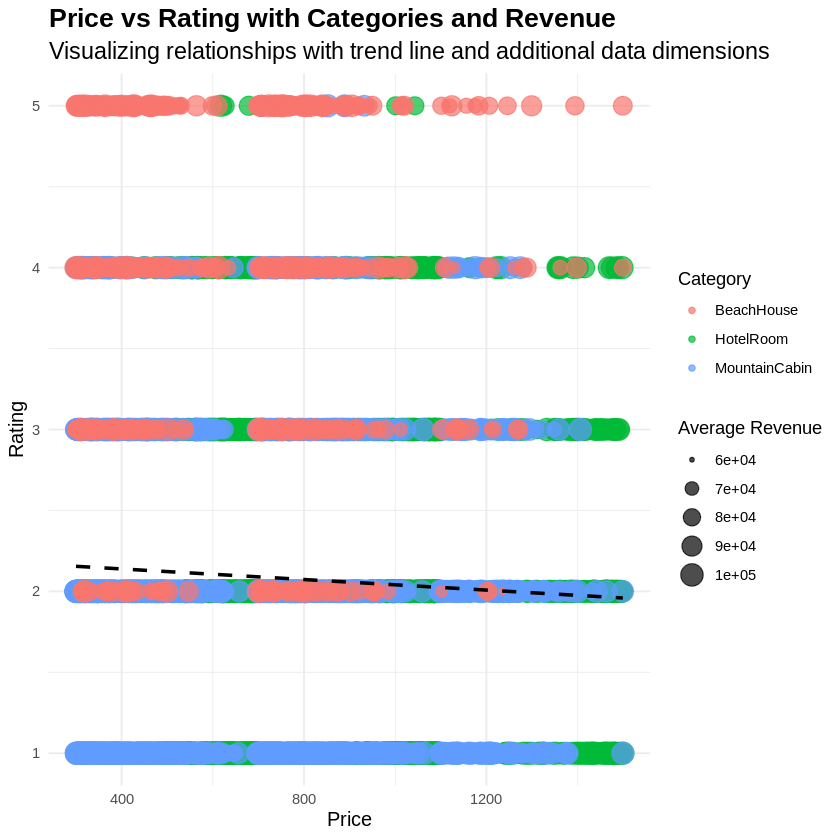

In [ ]:
library(ggplot2)

# Scatter plot showing price vs rating
ggplot(cleaned_data, aes(x = price, y = rating)) +
  geom_point(aes(color = category, size = average_revenue), alpha = 0.7) +
  geom_smooth(method = "lm", se = FALSE, linetype = "dashed", color = "black") + # Added a linear trend line to relationship between rating and price
  theme_minimal() +
  labs(
    title = "Price vs Rating with Categories and Revenue",
    subtitle = "Visualizing relationships with trend line and additional data dimensions",
    x = "Price",
    y = "Rating",
    color = "Category",
    size = "Average Revenue"
  ) +
  theme(
    plot.title = element_text(face = "bold", size = 16),
    plot.subtitle = element_text(size = 14),
    axis.title = element_text(size = 12)
  )



This scatter plot shows how price and rating are connected for three types of accommodations: Beach Houses (red), Hotel Rooms (green), and Mountain Cabins (blue). The size of the points represents their average revenue—larger points mean higher earnings.

Key Observations:

Beach Houses: These tend to have higher prices and fall within a mid-range of ratings. They bring in strong revenue, as shown by the relatively large points.

Hotel Rooms: Covering a huge range of prices, Hotel Rooms are present across almost all rating levels. Their revenue varies, reflected in the mixed point sizes.

Mountain Cabins: These usually sit in the middle of the price range, with moderately high ratings. Their revenue is a bit varied but leans towards smaller values at higher prices.

Interestingly, there seems to be a slight trend in one category where higher prices coincide with lower ratings, hinting at a trade-off. This visualization paints a vivid picture of how pricing, customer satisfaction, and profitability play off each other in the world of travel accommodations.


# 3. Pie Chart

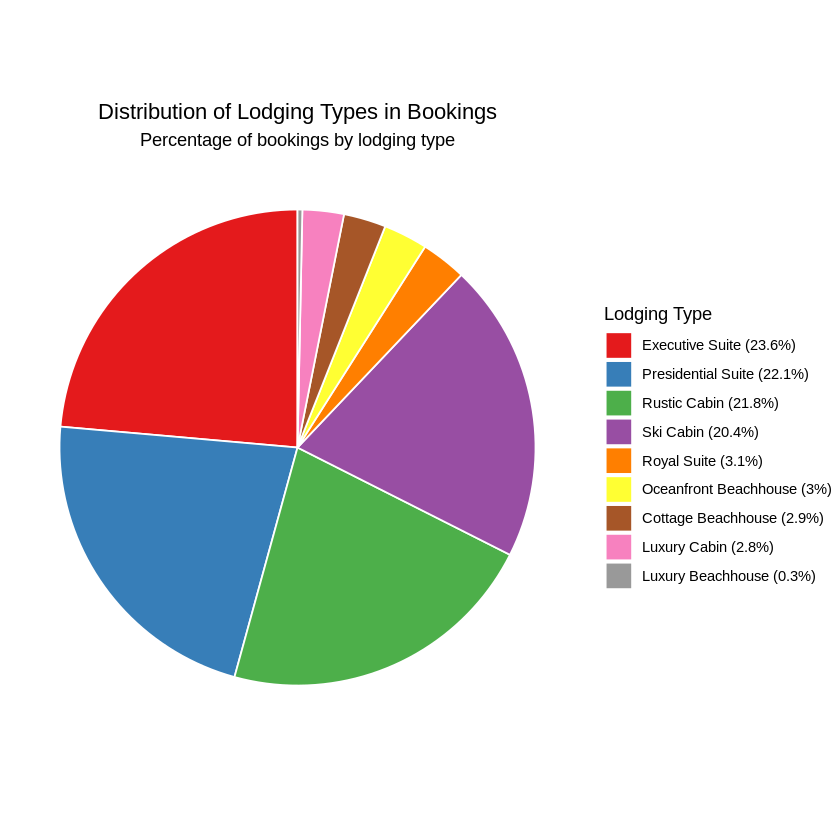

In [ ]:
library(dplyr)


# Prepare data
pie_data <- cleaned_data %>%
  group_by(name) %>%
  summarise(count = n()) %>%
  mutate(prop = count / sum(count) * 100,
         ypos = cumsum(prop) - 0.5 * prop) %>%
  mutate(label = paste0(name, " (", round(prop, 1), "%)")) %>%
  arrange(desc(prop)) %>%  # arrange from highest to lowest
  mutate(label = factor(label, levels = label))

# Plot
ggplot(pie_data, aes(x = "", y = prop, fill = label)) +
  geom_bar(stat = "identity", width = 1, color = "white") +
  coord_polar("y", start = 0) +
  theme_void() +
  theme(legend.position = "right",
        plot.title = element_text(hjust = 0.5),
        plot.subtitle = element_text(hjust = 0.5)) +
  scale_fill_brewer(palette = "Set1") +
  labs(title = "Distribution of Lodging Types in Bookings",
       subtitle = "Percentage of bookings by lodging type",
       fill = "Lodging Type")

The pie chart displays a breakdown of bookings for lodging types and highlights a clear trend: most bookings are concentrated in high-end options like the Executive Suite (23.6%), Rustic Cabin (22%), Presidential Suite (21.9%), and Ski Cabin (20.3%). These four categories make up over 80% of all bookings, highlighting a strong preference for premium accommodations (a step below luxury, offering comfort and quality without being super exclusive or expensive).

In contrast, more niche options, such as the Luxury Beachhouse (0.3%), Luxury Cabin (2.8%), and Cottage Beachhouse (2.9%),were booked far less frequently. This visualization suggests that travelers tend to favor more affordable indoor comfort over specialized, luxurious or beachfront options.

# 4. Heat Map

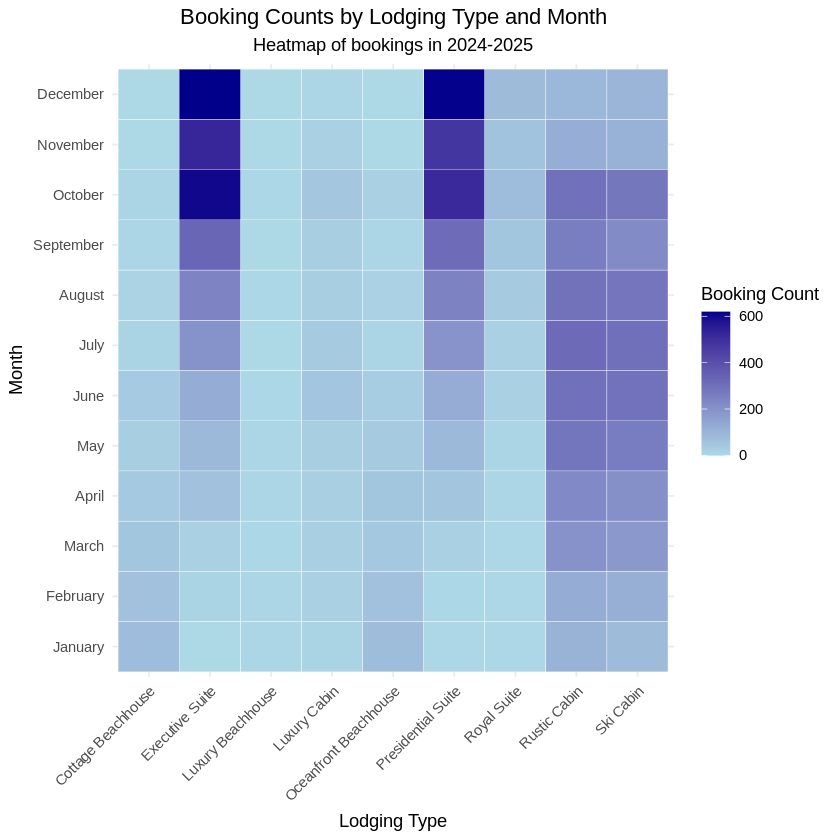

In [ ]:
heatmap_data <- cleaned_data %>%
  mutate(date = as.Date(date),
         month = factor(month.name[month(date)], levels = month.name)) %>%
  group_by(name, month) %>%
  summarise(count = n(), .groups = "drop") %>%
  complete(name, month, fill = list(count = 0))

ggplot(heatmap_data, aes(x = name, y = month, fill = count)) +
  geom_tile(color = "white") +
  scale_fill_gradient(low = "lightblue", high = "darkblue", name = "Booking Count") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        plot.title = element_text(hjust = 0.5),
        plot.subtitle = element_text(hjust = 0.5)) +
  labs(title = "Booking Counts by Lodging Type and Month",
       subtitle = "Heatmap of bookings in 2024-2025",
       x = "Lodging Type",
       y = "Month")

The heat map breaks down bookings by lodging type for each month in 2024–2025, highlighting the same trends depicted in the pie chart above.


The map emphasizes that options like the Executive Suite (23.6%), Rustic Cabin (22%), Presidential Suite (21.9%), and Ski Cabin (20.3%) get the most attention, with darker colors indicating more bookings in busy months like July through December.

Ski Cabins and Rustic Cabins are popular mid-year, while Executive and Presidential Suites do well in the winter.

Less common choices like the Luxury Beachhouse (0.3%), Luxury Cabin (2.8%), and Cottage Beachhouse (2.9%) recieve minimal bookings, even in peak beach months like June and July. Once again, both the pie chart and heat map make it clear that vacationers consistently choose cozier, indoor accommodations year-round, while more unique or beach-focused options see very limited interest regardless of the season.

# 5. Histogram

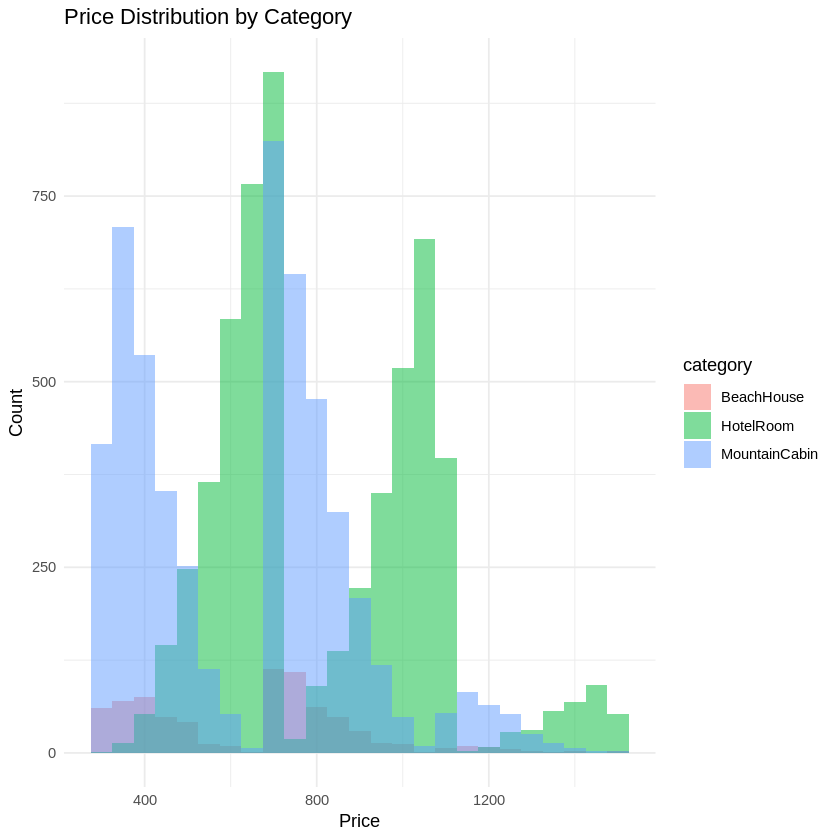

In [ ]:
# Histogram
ggplot(cleaned_data, aes(x = price, fill = category)) +
  geom_histogram(binwidth = 50, position = "identity", alpha = 0.5) +
  labs(title = "Price Distribution by Category", x = "Price", y = "Count") +
  theme_minimal()

This stacked histogram shows how lodging prices are distributed across three categories: Beach House (pink), Hotel Room (green), and Mountain Cabin (blue).
From the visualization, we can see that Beach Houses have the fewest bookings compared to the other two categories. Their prices generally fall between 400 and 700.

Hotel Rooms are very common in the 600 to 1,000 price range and they spread across an extensive range of prices. They also include the highest-priced listings, reaching above $1,400, which is more than any other category.

Mountain Cabins are most prevalent in the 400 to 800 range, showing strong representation in lower prices. However, their presence significantly declines as prices go above $1,000.

# 6. Line Plot

In [ ]:
# Clean and prep
data_rating_clean <- cleaned_data %>%
  filter(!is.na(date), !is.na(rating)) %>%
  mutate(date = ymd(date))

# Group by date
daily_rating <- data_rating_clean %>%
  group_by(date) %>%
  summarise(avg_rating = mean(rating, na.rm = TRUE), .groups = "drop")

# Line Plot
ggplot(daily_rating, aes(x = date, y = avg_rating)) +
  geom_line(color = "sky blue", size = 1) +
  labs(title = "Average Rating Over Time", x = "Date", y = "Average Rating") +
  theme_minimal()

This line plot shows how the average rating of listings changed between 2000 and 2013.

From 2000 to 2003, ratings were high but quite variable, with the peak occurring in 2002, reaching an average rating of 3.5.

Starting in 2004, we see a noticeable decline, with ratings dropping from around 3.3 to below 2.5. This trend could suggest growing customer dissatisfaction or changes in the market during that period.

Between 2008 and 2013, the average rating became more stable, consistently remaining below 2.4, which may reflect a sustained drop in overall customer satisfaction or possibly a shift in user rating behavior.

# 7. Box Plot

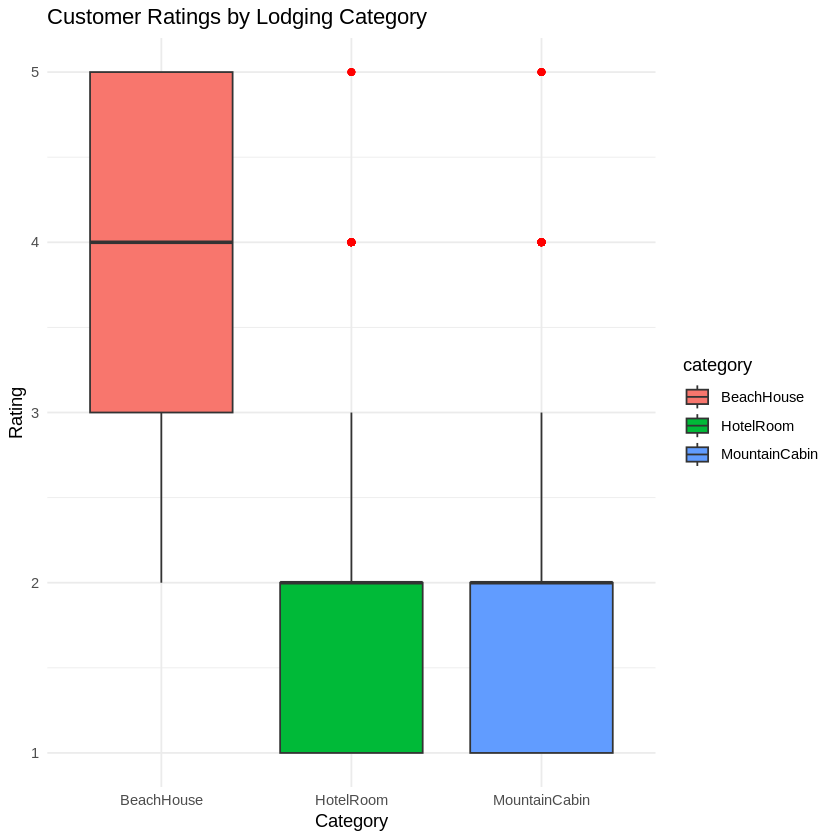

In [ ]:
#Boxplot
ggplot(cleaned_data, aes(x = category, y = rating, fill = category)) +
  geom_boxplot(outlier.color = "red") +
  labs(title = "Customer Ratings by Lodging Category",
       x = "Category", y = "Rating") +
  theme_minimal()

This boxplot illustrates the distribution of customer ratings across the three lodging categories: Beach House, Hotel Room, and Mountain Cabin. In a boxplot, the black horizontal line within each box represents the median rating. The red dots in the plot represent outliers—ratings that fall outside the typical range.

We observe that the Beach House category has a median rating of 4, while both Hotel Room and Mountain Cabin have a median rating of 2. Also, the outliers suggest that although there are a few high ratings for Hotel Rooms and Mountain Cabins, the majority of the feedback remains low.

For Beach Houses, ratings predominantly range between 3 and 5, making it the category with the highest overall customer satisfaction. In contrast, Hotel Rooms and Mountain Cabins generally have ratings between 1 and 2, indicating lower customer satisfaction.



---



# Brief Statistical Summary

In [ ]:
# Calculate average by name
meansn <- aggregate(cbind(price, average_revenue, rating) ~ name, cleaned_data, mean, na.rm = TRUE)
print(meansn)

cat("\n")

# Calculate average by name
meansc <- aggregate(cbind(price, average_revenue, rating) ~ category, cleaned_data, mean, na.rm = TRUE)
print(meansc)




                   name     price average_revenue   rating
1    Cottage Beachhouse  430.2725        80845.93 4.017391
2       Executive Suite  609.5064        89891.73 1.965749
3     Luxury Beachhouse 1150.0256        80002.27 3.717949
4          Luxury Cabin 1150.4807        89562.71 2.002967
5 Oceanfront Beachhouse  792.5028        81275.86 3.961111
6    Presidential Suite  971.6419        90059.36 1.951054
7           Royal Suite 1332.3415        91679.23 1.913279
8          Rustic Cabin  420.8358        89963.98 1.935090
9             Ski Cabin  790.9386        90007.89 1.993860

       category    price average_revenue   rating
1    BeachHouse 643.2742        81009.74 3.974462
2     HotelRoom 819.2653        90080.36 1.955779
3 MountainCabin 633.8477        89958.80 1.965920


# Conclusion

The analysis of the Lodging dataset reveals clear patterns in both customer preferences and business performance. Across multiple visualizations, upscale and spacious accommodations—such as the Executive Suite, Rustic Cabin, Presidential Suite, and Ski Cabin—dominate in both booking volume and revenue generation, indicating a strong and consistent demand for premium lodging options. These top-performing categories remain popular year-round, as shown in the heat map, with seasonal peaks aligning with holiday and travel periods.

From a customer satisfaction perspective, Beach Houses stand out with the highest median rating (around 4), suggesting a more consistently positive guest experience. In contrast, Hotel Rooms and Mountain Cabins, despite having wider price distributions and higher booking volumes in some ranges, generally receive lower ratings, indicating potential areas for improvement in quality or service.

Lastly, price distribution analysis shows that while Hotel Rooms dominate the higher price range (even exceeding $1,400), Mountain Cabins and Beach Houses are more concentrated in mid to lower price tiers. Yet, customer ratings favor Beach Houses, suggesting that pricing does not always correlate with satisfaction.

Although not included in the final report, an additional bar chart we created showed that Hotel Rooms were exclusively associated with Travel, while Vacation stays were primarily composed of Mountain Cabins and a smaller portion of Beach Houses.

Overall, our findings indicate that travelers strongly prefer upscale, cozy, indoor accommodations over Beach Houses & other niche offerings. However, it's evident that almost 50% of guests using this agency are booking for Travel, rather than Vacation Purposes. This could play a role in the low booking rates of more seasonal stays.

In conclusion, this agency should consider investing more in high-end offerings, while also improving service quality in mid-range options to boost satisfaction and long-term loyalty. To improve booking rates for less popular options (which are still highly rated), a rewards program or promotional offers could be introduced to entice customers into renting these lodging types.

# Recommendations


For researchers and marketers to gain further insight into booking trends, the dataset should incorporate the following:

* demographics of booking guests (age, gender, location, income level)

*  number of guests per booking
  - could potentially include group-friendly tourist attractions for larger parties as a marketing strategy

*   length of stay
*   geographic location of lodging type (city, state or country)
  - helps identify top-booked areas


*   detailed breakdown of travel purpose (business, leisure, family, event) - current dataset only lists "travel" or "vacation."

*   Whether guest participates in loyalty/rewards program + has used this agency before





Along with these additions, a potential modification to the dataset could involve adjusting the category column. Since luxury options are less accessible to the general public and receive far fewer bookings, they should be separated into their own category to prevent data skew.





